In [7]:
library(tidyverse)
library(dbplyr)

In [74]:
school_count <- read.csv("data/school_count.csv", header = TRUE)


In [63]:
outcomes <- read.csv("data/manual_classification.csv", header = TRUE)


In [64]:
head(school_count)

,person_id,SchoolName,n_schools
,<chr>,<chr>,<int>
1,F48A1CAEA9F5279772EA10D2BAA19242ABDDEFDE73A02C2EDD1047022BA8C2F6,Grange Technology College,2
2,966C673E1F91BCECFB3887D281FE0A39081A83B07359403F7833C67EF7818557,Appleton Academy,1
3,56F243860E60E36A69DA5A81850F00AF5B84D5F9B60B6B23DA21828857B53AFB,Bradford Academy,5
4,18746FF26D6AC95D757A4B4CB10B01DE6F041115B43ECC8BE0C4A0AEF575224B,The Co-operative Academy of Leeds,1
5,16AB3AC8B08A141C58F505036D9FC8AC09647F5485772F0849FC93AB9E7885EF,Appleton Academy,2
6,BFA4C3193490CCDA1B5422595F9E974355F83B6973445546D10283E5A3EE1296,Appleton Academy,1


In [75]:
school_count <- school_count |>
    select(-SchoolName) |>
    distinct()

In [76]:
head(outcomes)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X6,X7,X8,Education,Employment,Training,Refused,NEET,NA_count,Label
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET: Not ready,⋯,NEET: Seeking EET,NEET: Seeking EET,NEET: Seeking EET,6,0,0,0,6,0,Risky trajectory
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,Education,NA,10,0,0,0,0,2,Steady EET
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,Education,12,0,0,0,0,0,Steady EET


In [77]:
merge <- outcomes |>
    left_join(school_count, by=join_by(person_id))

In [78]:
head(merge)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X7,X8,Education,Employment,Training,Refused,NEET,NA_count,Label,n_schools
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,12,0,0,0,0,0,Steady EET,2
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,12,0,0,0,0,0,Steady EET,2
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET: Not ready,⋯,NEET: Seeking EET,NEET: Seeking EET,6,0,0,0,6,0,Risky trajectory,1
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,12,0,0,0,0,0,Steady EET,2
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,⋯,Education,NA,10,0,0,0,0,2,Steady EET,1
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,Education,12,0,0,0,0,0,Steady EET,2


In [79]:
merge |>
     group_by(n_schools) |>
    tally()

n_schools,n
<int>,<int>
1,10792
2,5050
3,808
4,219
5,70
6,18
7,2
8,3
NA,399


In [80]:
merge |> filter(is.na(n_schools)) |>
    group_by(Label) |>
    tally()

Label,n
<chr>,<int>
DROP,64
Risky trajectory,39
Steady EET,296


In [81]:
merge |> filter(Label == 'Risky trajectory') |>
    group_by(n_schools) |>
    tally()

n_schools,n
<int>,<int>
1,586
2,448
3,177
4,76
5,26
6,7
7,1
8,1
NA,39


In [82]:
merge |> filter(Label == 'Steady EET') |>
    group_by(n_schools) |>
    tally()

n_schools,n
<int>,<int>
1,10078
2,4530
3,612
4,136
5,40
6,11
7,1
8,2
NA,296


# Simpson's Diversity Index

Simpson's Index quantifies diversity by measuring the probability that two randomly selected "items" (in this case, school-year entries) belong to the same category (school). A higher index means less diversity (more consistency); a lower index means more diversity (more variation in schools).

In [83]:
simpson_person <- merge |>
    select(person_id, NCCIS_ACADYR, Label)

In [84]:
enrolments <- read.csv("data/enrol_final.csv", header = TRUE)

In [85]:
head(enrolments)

,person_id,SchoolID,AcademicYear,OnRoll_1,OnRoll_2,OnRoll_3,EnrolStatus,EntryDate,LeavingDate,PartTime,NCCIS_ACADYR,URN,InstitutionTypeDesc,SchoolName,PhaseOfEducationDesc,LatestURN
,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,F48A1CAEA9F5279772EA10D2BAA19242ABDDEFDE73A02C2EDD1047022BA8C2F6,15177,2016/2017,1,1,1,C,2012-10-03,NA,0,2017/2018,139982,Academy converter,Grange Technology College,Secondary,107414
2,966C673E1F91BCECFB3887D281FE0A39081A83B07359403F7833C67EF7818557,10875,2014/2015,1,1,1,C,2014-11-10,NA,0,2017/2018,135865,Academy sponsor led,Appleton Academy,Not applicable,135865
3,56F243860E60E36A69DA5A81850F00AF5B84D5F9B60B6B23DA21828857B53AFB,9574,2015/2016,0,NA,NA,M,2012-10-04,2015-11-06,0,2017/2018,135367,Academy sponsor led,Bradford Academy,Not applicable,135367
4,18746FF26D6AC95D757A4B4CB10B01DE6F041115B43ECC8BE0C4A0AEF575224B,14276,2015/2016,1,1,1,C,2012-10-04,NA,0,2017/2018,137065,Academy sponsor led,Co-op Academy Leeds,Secondary,137065
5,16AB3AC8B08A141C58F505036D9FC8AC09647F5485772F0849FC93AB9E7885EF,18286,2017/2018,1,1,1,C,2017-09-01,NA,0,2018/2019,145173,Academy sponsor led,Appleton Academy,NA,135865
6,BFA4C3193490CCDA1B5422595F9E974355F83B6973445546D10283E5A3EE1296,18286,2017/2018,1,1,0,C,2017-09-01,2018-06-29,0,2018/2019,145173,Academy sponsor led,Appleton Academy,NA,135865


In [86]:
enrolments |>
    filter(person_id == '0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57')

person_id,SchoolID,AcademicYear,OnRoll_1,OnRoll_2,OnRoll_3,EnrolStatus,EntryDate,LeavingDate,PartTime,NCCIS_ACADYR,URN,InstitutionTypeDesc,SchoolName,PhaseOfEducationDesc,LatestURN
<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57,17763,2016/2017,1,0,NA,C,2013-09-05,2017-02-24,0,2018/2019,142590,Academy converter,Immanuel College,Secondary,132219
0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57,1164,2014/2015,1,1,1,C,2013-09-05,NA,0,2018/2019,132219,Voluntary aided school,Immanuel College,Secondary,132219
0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57,1164,2013/2014,1,1,1,C,2013-09-05,NA,0,2018/2019,132219,Voluntary aided school,Immanuel College,Secondary,132219
0A69F30C79C7050090460E9093EA1D5639D43AC626C3067E754604156142CA57,1164,2015/2016,1,1,1,C,2013-09-05,NA,0,2018/2019,132219,Voluntary aided school,Immanuel College,Secondary,132219


In [87]:
enrolments |>
    filter(person_id == '0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517')

person_id,SchoolID,AcademicYear,OnRoll_1,OnRoll_2,OnRoll_3,EnrolStatus,EntryDate,LeavingDate,PartTime,NCCIS_ACADYR,URN,InstitutionTypeDesc,SchoolName,PhaseOfEducationDesc,LatestURN
<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,14714,2017/2018,1,1,0,C,2017-09-07,2018-06-29,0,2018/2019,121270,AP/PRU,Danesgate Community,Not applicable,121270
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,16856,2015/2016,0,NA,NA,S,2015-06-30,2015-11-20,0,2018/2019,142135,AP/PRU,The Hub School,Not applicable,142135
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,2266,2013/2014,1,1,1,C,2013-09-01,NA,0,2018/2019,118080,Community school,South Holderness Technology College,Secondary,118080
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,15777,2016/2017,1,0,NA,C,2016-04-12,2017-01-20,0,2018/2019,141037,AP/PRU,Aspire Academy,Not applicable,141037
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,2266,2014/2015,1,1,1,C,2013-09-01,NA,0,2018/2019,118080,Community school,South Holderness Technology College,Secondary,118080
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,15777,2015/2016,NA,NA,1,C,2016-04-12,NA,0,2018/2019,141037,AP/PRU,Aspire Academy,Not applicable,141037
0F719CE1354E346BC9788D861696C41D3E12CD4E9B922C321905506B99B7F517,2266,2015/2016,1,0,NA,M,2013-09-01,2016-03-24,0,2018/2019,118080,Community school,South Holderness Technology College,Secondary,118080


In [90]:
simpsons_school <- enrolments |>
    select(person_id, SchoolName, AcademicYear)

In [89]:
library(vegan)

In [91]:
# Create a school frequency table per student
student_school_matrix <- simpsons_school %>%
  group_by(person_id, SchoolName) %>%
  summarise(freq = n()) %>%
  tidyr::pivot_wider(names_from = SchoolName, values_from = freq, values_fill = 0) %>%
  as.data.frame()

`summarise()` has grouped output by 'person_id'. You can override using the
`.groups` argument.


In [92]:
head(student_school_matrix)

,person_id,Beckfoot Thornton,Thornton Grammar School,St Bede's and St Joseph's Catholic College,St Joseph's Catholic College,Sunbury Manor School,Beckfoot Oakbank,Oakbank School,Priesthorpe School,Tong High School,⋯,Macmillan Academy,Swadelands School,The John Wallis Church of England Academy,The Lenham School,Beverley High School,Ark Walworth Academy,Launceston College,Savio Salesian College,West Kirby Grammar School,Hothfield Junior School
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,1,4,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,0,0,3,2,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,0,0,0,0,5,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,0,0,0,0,0,2,3,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,0,0,0,0,0,0,0,5,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,0,0,0,0,0,0,0,0,4,⋯,0,0,0,0,0,0,0,0,0,0


In [93]:
# Remove person_id column temporarily for calculation
person_ids <- student_school_matrix$person_id
school_counts <- student_school_matrix[, -1]

In [94]:
# Calculate Simpson's Diversity Index
simpson_index <- diversity(school_counts, index = "simpson")

# Combine back with person_ids
simpson_df <- data.frame(person_id = person_ids, simpson_index = simpson_index)

In [95]:
simpson_df

person_id,simpson_index
<chr>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,0.3200000
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,0.4800000
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,0.0000000
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,0.4800000
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,0.0000000
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,0.3200000
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,0.3200000
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,0.0000000
001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,0.0000000


In [96]:
# Step 1: Summarize number of times each student is seen at each school
school_freq <- simpsons_school %>%
  group_by(person_id, SchoolName) %>%
  summarise(freq = n(), .groups = "drop")

In [97]:
# Step 2: Pivot to wide format (person_id × school matrix)
school_matrix <- school_freq %>%
  pivot_wider(names_from = SchoolName, values_from = freq, values_fill = 0) %>%
  as.data.frame()

In [98]:
# Step 3: Calculate Simpson’s Diversity Index
person_ids <- school_matrix$person_id
school_counts <- school_matrix[, -1]

In [99]:
simpson_index <- diversity(school_counts, index = "simpson")

In [100]:
# Step 4: Combine with person_id
result <- data.frame(person_id = person_ids, simpson_index = simpson_index)

In [101]:
enrolments |> 
    filter(person_id == '0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D')

person_id,SchoolID,AcademicYear,OnRoll_1,OnRoll_2,OnRoll_3,EnrolStatus,EntryDate,LeavingDate,PartTime,NCCIS_ACADYR,URN,InstitutionTypeDesc,SchoolName,PhaseOfEducationDesc,LatestURN
<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,15042,2014/2015,1,1,1,C,2013-09-03,NA,0,2018/2019,136529,Academy converter,Sunbury Manor School,Secondary,136529
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,15042,2017/2018,1,1,0,C,2013-09-03,2018-06-29,0,2018/2019,136529,Academy converter,Sunbury Manor School,Secondary,136529
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,15042,2013/2014,1,1,1,C,2013-09-03,NA,0,2018/2019,136529,Academy converter,Sunbury Manor School,Secondary,136529
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,15042,2015/2016,1,1,1,C,2013-09-03,NA,0,2018/2019,136529,Academy converter,Sunbury Manor School,Secondary,136529
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,15042,2016/2017,1,1,1,C,2013-09-03,NA,0,2018/2019,136529,Academy converter,Sunbury Manor School,Secondary,136529


In [102]:
result

person_id,simpson_index
<chr>,<dbl>
0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,0.3200000
00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,0.4800000
0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,0.0000000
0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,0.4800000
00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,0.0000000
0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,0.3200000
0018E26A40A6299391164D4918658B0B1248367C762DCE6D2FDF1AE131A9138C,0.3200000
0019031CD62586D59268772800516ED50CDF1EF7DE46488542BB031850F6E68A,0.0000000
001B7CEB7B4CC529920A0B9F5B83D1AC0019E5DC44B3FBB3CEF665C331C0C3B6,0.0000000


In [103]:
summary(simpson_df)

  person_id         simpson_index   
 Length:16962       Min.   :0.0000  
 Class :character   1st Qu.:0.0000  
 Mode  :character   Median :0.0000  
                    Mean   :0.1597  
                    3rd Qu.:0.3200  
                    Max.   :0.8642  

In [104]:
summary(result)

  person_id         simpson_index   
 Length:16962       Min.   :0.0000  
 Class :character   1st Qu.:0.0000  
 Mode  :character   Median :0.0000  
                    Mean   :0.1597  
                    3rd Qu.:0.3200  
                    Max.   :0.8642  

In [105]:
enrolments_simpsons <- merge |>
    left_join(simpson_df, by=join_by(person_id))

In [106]:
head(enrolments_simpsons)

,person_id,NCCIS_ACADYR,Intended_destination,X9,X10,X11,X12,X1,X2,X3,⋯,X8,Education,Employment,Training,Refused,NEET,NA_count,Label,n_schools,simpson_index
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<dbl>
1,0002F12C1F92EC01CB0C05D441AA6D7AE16E9CD131BB64885744D08BA74E1FDD,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,12,0,0,0,0,0,Steady EET,2,0.32
2,00034E776A98176C2B6075634BC4A614400F32AA9C4D599FDDE156541F1F9A29,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,12,0,0,0,0,0,Steady EET,2,0.48
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,2018/2019,NA,Education,Education,Education,Education,Education,Education,NEET: Not ready,⋯,NEET: Seeking EET,6,0,0,0,6,0,Risky trajectory,1,0.00
4,0013020C6ED2FF78BCA8E5F2D0B9B16E66C50B6A2AABB754FB63314CFE3A2EC7,2018/2019,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,12,0,0,0,0,0,Steady EET,2,0.48
5,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,2017/2018,NA,NA,Education,Education,Education,Education,Education,Education,⋯,NA,10,0,0,0,0,2,Steady EET,1,0.00
6,0014DF7EADF7C22A0FD2F6862B6F06778B199F1F2D61242125DA8EC539E6275D,2017/2018,NA,Education,Education,Education,Education,Education,Education,Education,⋯,Education,12,0,0,0,0,0,Steady EET,2,0.32


# Visualise trajectories

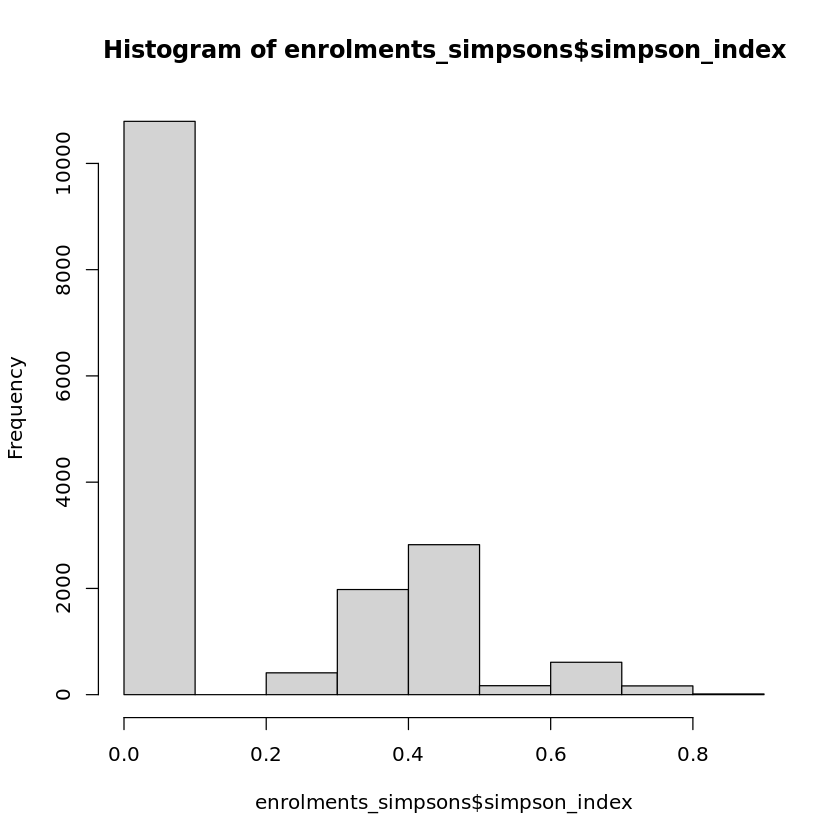

In [107]:
hist(enrolments_simpsons$simpson_index, breaks = 10)

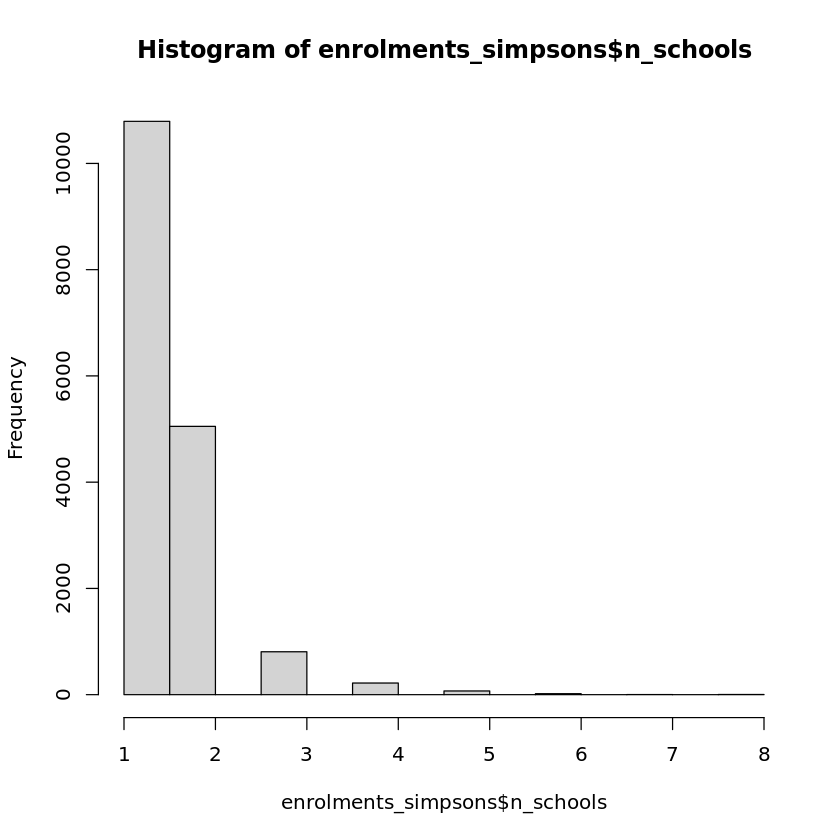

In [108]:
hist(enrolments_simpsons$n_schools, breaks = 10)

In [41]:
library(ggplot2)

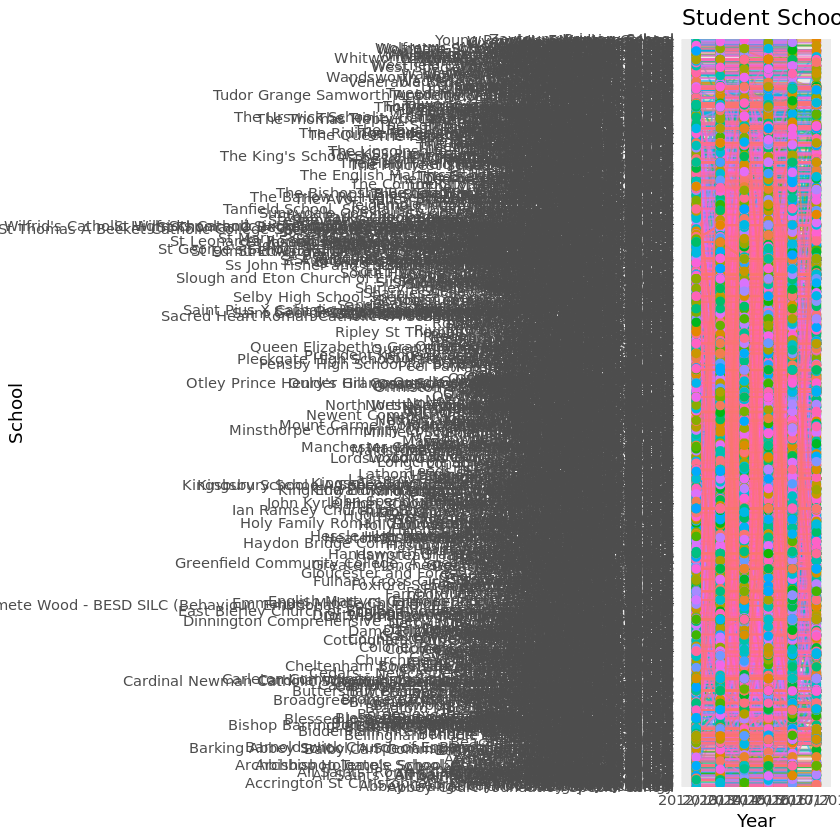

In [109]:
# Plot: one line per student
ggplot(simpsons_school, aes(x = AcademicYear, y = SchoolName, group = person_id, color = person_id)) +
  geom_line(alpha = 0.6) +
  geom_point(size = 2) +
  labs(title = "Student School Trajectories Over Time",
       x = "Year", y = "School") +
  theme_minimal() +
  theme(legend.position = "none")  # hide legend if too many students

In [110]:
students_simpson_indexes <- simpsons_school |>
    left_join(simpson_df, by = "person_id")

In [111]:
head(students_simpson_indexes)

,person_id,SchoolName,AcademicYear,simpson_index
,<chr>,<chr>,<chr>,<dbl>
1,F48A1CAEA9F5279772EA10D2BAA19242ABDDEFDE73A02C2EDD1047022BA8C2F6,Grange Technology College,2016/2017,0.2777778
2,966C673E1F91BCECFB3887D281FE0A39081A83B07359403F7833C67EF7818557,Appleton Academy,2014/2015,0.0000000
3,56F243860E60E36A69DA5A81850F00AF5B84D5F9B60B6B23DA21828857B53AFB,Bradford Academy,2015/2016,0.7160494
4,18746FF26D6AC95D757A4B4CB10B01DE6F041115B43ECC8BE0C4A0AEF575224B,Co-op Academy Leeds,2015/2016,0.0000000
5,16AB3AC8B08A141C58F505036D9FC8AC09647F5485772F0849FC93AB9E7885EF,Appleton Academy,2017/2018,0.3200000
6,BFA4C3193490CCDA1B5422595F9E974355F83B6973445546D10283E5A3EE1296,Appleton Academy,2017/2018,0.0000000


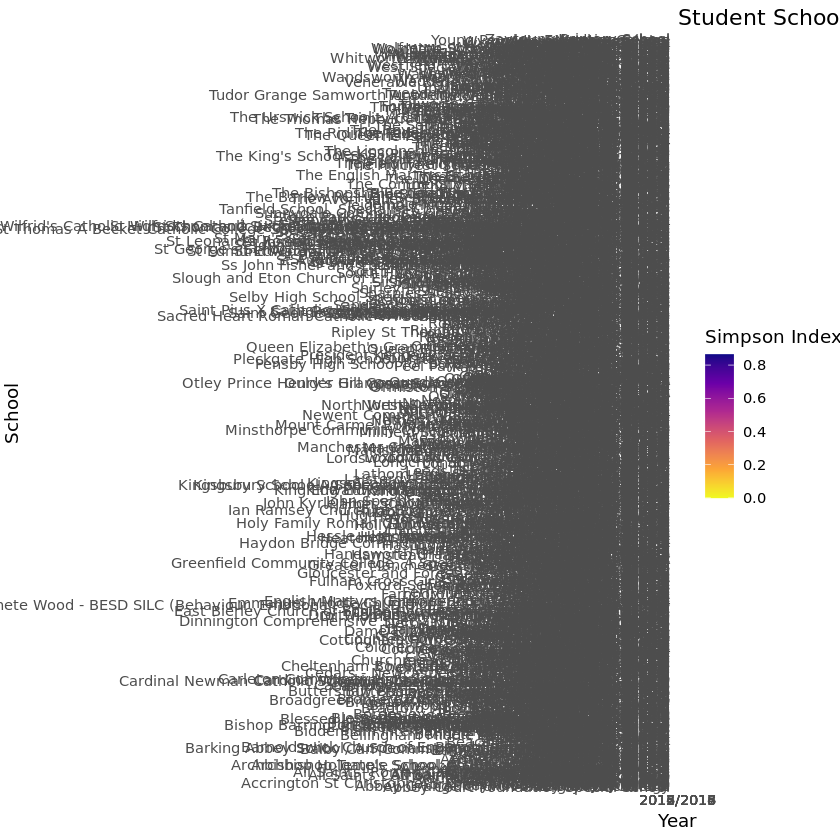

In [112]:
# 3. Plot trajectories with color = Simpson index
ggplot(students_simpson_indexes, aes(x = AcademicYear, y = SchoolName, group = person_id, color = simpson_index)) +
  geom_line(alpha = 0.8, linewidth = 1) +
  geom_point(size = 2) +
  scale_color_viridis_c(option = "plasma", direction = -1) +  # prettier color scale
  labs(
    title = "Student School Trajectories Colored by Simpson's Diversity Index",
    x = "Year", y = "School",
    color = "Simpson Index"
  ) +
  theme_minimal()

In [113]:
students_simpson_indexes <- students_simpson_indexes |>
    arrange(simpson_index, person_id) |>
    mutate(person_id = factor(person_id, levels = unique(person_id)))
    # convert to factor instead of number so can color in plot
   # mutate(SchoolID = as.factor(SchoolID))

In [114]:
head(students_simpson_indexes)

,person_id,SchoolName,AcademicYear,simpson_index
,<fct>,<chr>,<chr>,<dbl>
1,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,Sunbury Manor School,2014/2015,0
2,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,Sunbury Manor School,2017/2018,0
3,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,Sunbury Manor School,2013/2014,0
4,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,Sunbury Manor School,2015/2016,0
5,0004E60FEFC16781A48973C80F782B233869629C9CE44B741E2D2043047FCB1D,Sunbury Manor School,2016/2017,0
6,00149D26484ED3BE2DEF154B8DB53A36B1A9FF0839C447A2CE19B0750225BA66,Priesthorpe School,2016/2017,0


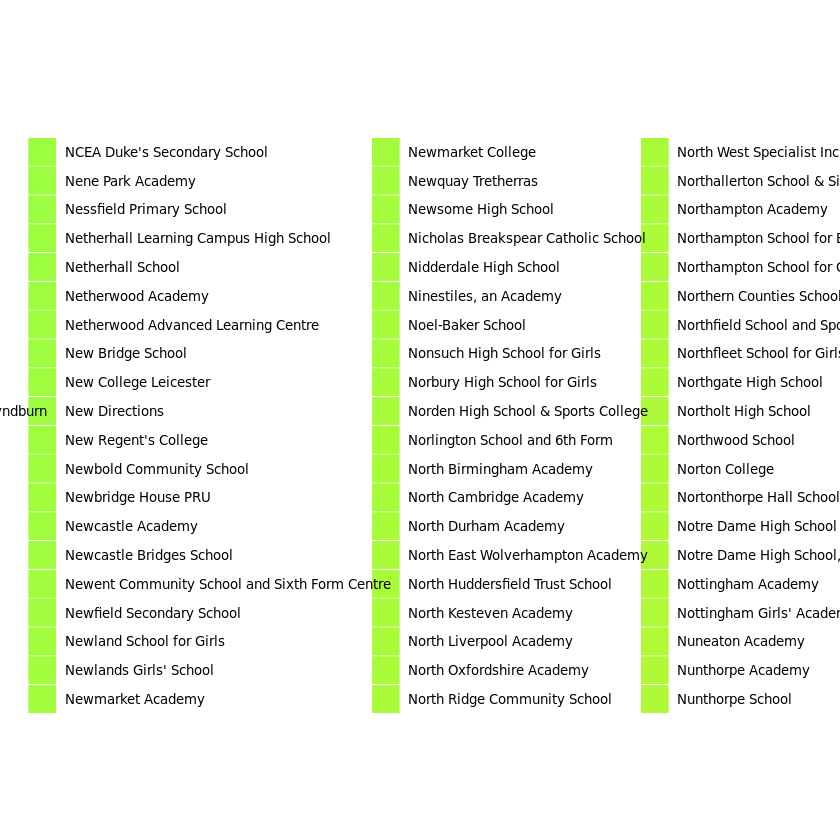

In [115]:
# Plot as tile heatmap
ggplot(students_simpson_indexes, aes(x = AcademicYear, y = person_id, fill = SchoolName)) +
  geom_tile(color = "white", size = 0.1) +
  scale_fill_viridis_d(option = "turbo") +
  labs(
    title = "Student School Trajectories (Heatmap View)",
    x = "Year", y = "Student",
    fill = "School"
  ) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid = element_blank()
  )